# TROPESS HDO + VMR - AIRS

low>mid troposphere averaged column - gridded data (13.5km x 13.5km) plots

- Using the pixel size 

- https://github.com/NASA-TROPESS/tutorials_notebooks \
- https://github.com/NASA-TROPESS/tropess-notes/blob/main/book/canadian-fires-gridded-plot-carbon-monoxide-column.ipynb \
- https://disc.gsfc.nasa.gov/datasets/TRPSYL2HDOAIRSORS_1/summary


In [1]:
import datetime
import sys
import contextlib
from pathlib import Path
import pandas as pd
import xarray as xr
import numpy as np
from netCDF4 import Dataset
import glob
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

from scipy.interpolate import griddata
from scipy.spatial import cKDTree


In [2]:
# Specify date range
start_date = datetime.date(2018, 1, 1)
#end_date = datetime.date(2018, 5, 2)
end_date = datetime.date(2024, 12, 31)

dD_list = []
# Loop through the date range and plot Carbon Monoxide for each day
for t,current_date in enumerate(pd.date_range(start_date, end_date)):
    data_file_date = current_date.strftime("%Y%m%d")
    
    try:
        # We may not have data for certain days   
        pathlist = glob.glob(f'/Volumes/New_5TB/ESA_F4R/tropess/TROPESS_AIRS-Aqua_L2_Summary_HDO_{data_file_date}_MUSES_*')
        data_file_path = pathlist[0]
        #print(data_file_path)
        
        # Open the netCDF file
        dataset = Dataset(data_file_path, 'r')
        
        # Read the data from your variables
        latitude = dataset.variables['latitude'][:]
        longitude = dataset.variables['longitude'][:]
        pressure = dataset.variables['pressure'][:,:]
        xratio_in = dataset.variables['x'][:,:]
        xvmr_in = dataset.variables['x_h2o'][:,:]
        daynight_in = dataset.groups['geophysical']['day_night_flag'][:]
        landflag_in = dataset.groups['geophysical']['land_flag'][:]
        
        daynight = np.where((daynight_in==1) & (landflag_in==1))[0]
        xratio_lev = xratio_in[daynight,:]    
        xvmr_lev = xvmr_in[daynight,:]    
        pressure = pressure[daynight,:]    
        latitude = latitude[daynight]
        longitude = longitude[daynight] 
        
        #lowmid = np.where(
        #        (pressure > 550) & (pressure < 825))[0]
        #lowmid = np.where(
        #        (pressure > 825))
        #print(np.shape(lowmid))
        #print(lowmid[0])
        #print(lowmid[1])
        #print(np.shape(pressure))
        #print(np.shape(xratio_lev))
        print(pressure[0,3:8])
        #sys.exit()
        #xratio_lev = xratio_in[:,lowmid]    
        xratio = np.mean(xratio_lev[:,3:8],axis=1)
        #xvmr_lev = xvmr_in[:,lowmid]    
        xvmr = np.mean(xvmr_lev[:,3:8],axis=1)
        
        # calculate deltaD
        R = xratio
        # use this RSMOW for molecules of water
        Rvsmow = 3.11*10**(-4)
        dD = (R/Rvsmow - 1)*1000.
        
        # Filter the data for South America only
        latitude_max = 13.0
        latitude_min = -15.0
        longitude_max = 32.0
        longitude_min = 8.0
        
        centralaf = np.where(
            (latitude > latitude_min) & (latitude < latitude_max) & 
            (longitude > longitude_min) &(longitude < longitude_max))[0]
        
        latitude = latitude[centralaf]
        longitude = longitude[centralaf]
        dD_col = dD[centralaf]
        vmr_col = xvmr[centralaf]
        
        # Get AIRS pixel size in degrees, pixel is 13.5 x 13.5 km, 1 degree is roughly 111.1 km
        cris_pixel_size_deg = 13.5/111.1
        
        # Get the grid for the interpolated values
        grid_lat, grid_lon = np.mgrid[latitude_min:latitude_max-1:cris_pixel_size_deg, longitude_min:longitude_max-1:cris_pixel_size_deg]
        
        # Interpolate the data using griddata
        try:
            grid_dD_col = griddata((latitude, longitude), dD_col, (grid_lat, grid_lon), method='linear', rescale=True)
            grid_vmr_col = griddata((latitude, longitude), vmr_col, (grid_lat, grid_lon), method='linear', rescale=True)
        
            # Find the distance to the nearest original point for each point in the interpolated grid
            tree = cKDTree(np.vstack((latitude, longitude)).T)
            dist, _ = tree.query(np.vstack((grid_lat.ravel(), grid_lon.ravel())).T)
            
            # Reshape the distance array to have the same shape as the x_col grid
            dist_grid = dist.reshape(grid_dD_col.shape)
            
            # Mask the interpolated values that are too far from any original point
            max_distance_degrees = 3.0
            grid_dD_col[dist_grid > max_distance_degrees] = np.nan
            grid_vmr_col[dist_grid > max_distance_degrees] = np.nan
            
            dD_xr = xr.Dataset(
                            data_vars=dict(deltaD=(["lat","lon"],grid_dD_col),H2O=(["lat","lon"],grid_vmr_col)),
                            coords=dict(
                                time=current_date,
                                lat=(["lat"], grid_lat[:,0]),
                                lon=(["lon"], grid_lon[0,:])
                            ),
                            attrs=dict(
                                description="deltaD",
                                units="permil",
                            ),
                        ) 
            #print(dD_xr)
            dD_list.append(dD_xr)
        except:
            print('region empty for: ',current_date)
        dataset.close()
    except:
        print('no file for: ',current_date)
dD_out = xr.concat(dD_list,dim='time')
print(dD_out)
dD_out.to_netcdf('/Users/ellendyer/Documents/GitHub/F4R_data/tropess_gridded_caf_lowmid.nc',engine='scipy')

no file for:  2018-01-01 00:00:00
no file for:  2018-01-02 00:00:00
no file for:  2018-01-03 00:00:00
no file for:  2018-01-04 00:00:00
no file for:  2018-01-05 00:00:00
no file for:  2018-01-06 00:00:00
no file for:  2018-01-07 00:00:00
no file for:  2018-01-08 00:00:00
no file for:  2018-01-09 00:00:00
no file for:  2018-01-10 00:00:00
no file for:  2018-01-11 00:00:00
no file for:  2018-01-12 00:00:00
no file for:  2018-01-13 00:00:00
no file for:  2018-01-14 00:00:00
no file for:  2018-01-15 00:00:00
no file for:  2018-01-16 00:00:00
no file for:  2018-01-17 00:00:00
no file for:  2018-01-18 00:00:00
no file for:  2018-01-19 00:00:00
no file for:  2018-01-20 00:00:00
no file for:  2018-01-21 00:00:00
no file for:  2018-01-22 00:00:00
no file for:  2018-01-23 00:00:00
no file for:  2018-01-24 00:00:00
no file for:  2018-01-25 00:00:00
no file for:  2018-01-26 00:00:00
no file for:  2018-01-27 00:00:00
no file for:  2018-01-28 00:00:00
no file for:  2018-01-29 00:00:00
no file for:  

ValueError: must supply at least one object to concatenate

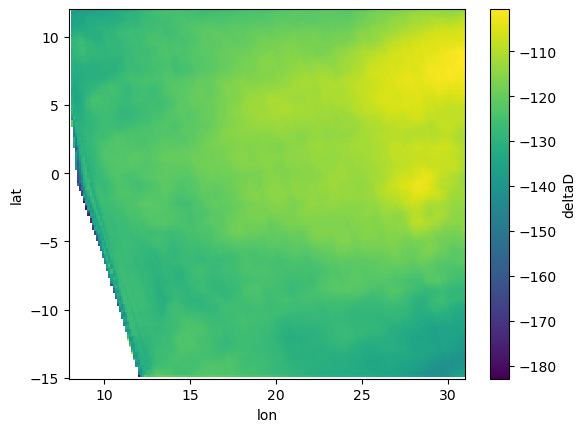

In [ ]:
dD_out['deltaD'].mean('time').plot()
plt.show()
